In [16]:
import colorcet
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from lib.plots import set_axis, attach_colorbar

In [18]:
metrics_filename = "metricsX.csv"

metrics_table = pl.read_csv(metrics_filename)

In [28]:
key_labels = {
}

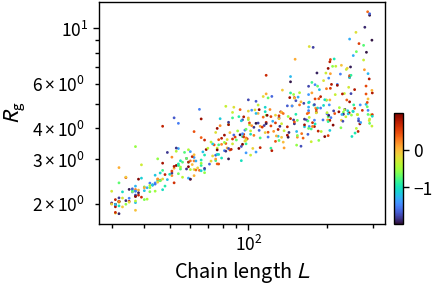

In [92]:
z_key = "linear_diffusivity"

fig, ax = plt.subplots()

x = metrics_table["chain_length"]
y = metrics_table["rg"]
z = np.log10(metrics_table[z_key])
sm = ax.scatter(x, y, c=z, s=1, cmap="turbo")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Chain length $ L $")
ax.set_ylabel(r"$ R_\mathrm{g} $")

cbar = attach_colorbar(ax, sm)

pass

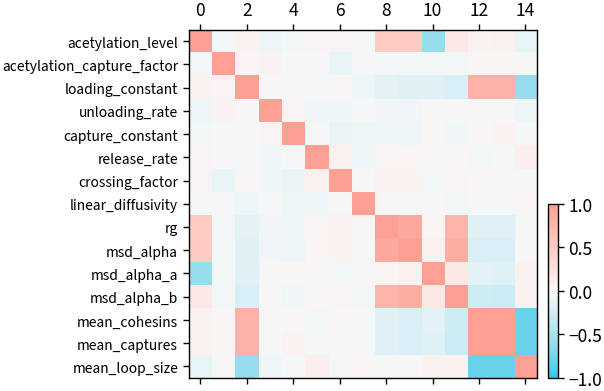

In [84]:
X = (
    metrics_table
    .drop("config_id")
    .with_columns(
        rg=(pl.col("rg") / pl.col("chain_length")**0.5),
        mean_cohesins=(pl.col("mean_cohesins") / pl.col("chain_length")),
        mean_captures=(pl.col("mean_captures") / pl.col("chain_length")),
    )
    .drop("chain_length")
    .select(pl.all().rank())
    .corr()
)
fig, ax = plt.subplots(figsize=(3.0, 2.0))
sm = ax.matshow(X, vmin=-1, vmax=1, cmap=colorcet.m_cwr)
ax.set_yticks(np.arange(len(X.columns)))
ax.set_yticklabels(X.columns, fontsize="x-small")
attach_colorbar(ax, sm)
pass

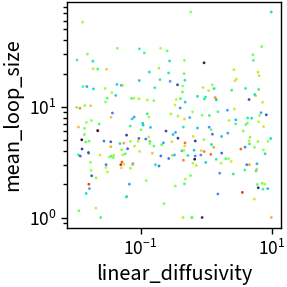

In [42]:
x_key = "linear_diffusivity"
y_key = "mean_loop_size"
z_key = "rg"

fig, ax = plt.subplots(figsize=(1.5, 1.5))

x = metrics_table[x_key]
y = metrics_table[y_key]
z = np.log10(metrics_table[z_key])
ax.scatter(x, y, c=z, s=1, ec="none", cmap="turbo")

ax.set_xlabel(key_labels.get(x_key, x_key))
ax.set_ylabel(key_labels.get(y_key, y_key))
ax.set_xscale("log")
ax.set_yscale("log")

pass